# FMATCH 3/10 — Swath-product readers (CERES SSF, CLDPIX, VIIRS cloud)

**PR topic**: the three readers for datasets organized along a **satellite ground track**
rather than on a regular lat/lon grid, completing the nine-reader registry started in the
previous PR.

Same **before → after** contract as the gridded readers: an external file in its own
native format goes *in*, a uniform `GridTile` on a regular lat/lon grid comes *out*. But
the "in" side here is *swath* data — a 1-D list of footprints, or a 2-D
`(scanline, pixel)` image — that does not line up with any lat/lon grid. Two of the three
readers therefore **rasterize a point cloud** (the same `rasterize_points_to_grid` helper
the projected readers use), and the third reads an already-gridded product that simply
hides its data in nested groups.

| reader key | dataset | native organization | reader strategy |
|---|---|---|---|
| `ssf` | [CERES SSF](https://ceres.larc.nasa.gov/data/) / [FLASHFlux](https://ceres.larc.nasa.gov/data/) TOA+surface fluxes & clouds | 1-D footprint list (~20 km) | rasterize points |
| `cldpix` | CERES CLDPIX imager cloud pixels | 2-D `(scanline, pixel)` swath | rasterize points |
| `viirs_cloud` | [VIIRS cloud properties](https://ladsweb.modaps.eosdis.nasa.gov/missions-and-measurements/products/CLDPROP_D3_VIIRS_NOAA20) (D3 daily grid) | gridded L3 (grouped, transposed) | read + transpose |

**The key idea — rasterize to stay uniform**: SSF and CLDPIX parse the whole file once
(cached on the instance), normalize the geolocation conventions, and bin the points onto a
regular sub-grid covering each requested 2° tile. Cells with no footprint stay NaN, so
coverage is preserved honestly and later feeds the per-variable coverage accounting in the
aggregation stage.

The same SSF reader serves both the standard SSF product and the RBSP **FLASHFlux** stream
(identical file format, lower latency) — FLASHFlux feeds FMATCH-IMAGER-FLASH.

In [1]:
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import netCDF4
import numpy as np

# Notebook lives in notebooks/; the synthetic-fixture generators live in tests/.
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
import libera_utils.footprint_matching.readers  # noqa: F401  (import triggers registration)
from libera_utils.footprint_matching.readers.registry import ReaderRegistry
from libera_utils.footprint_matching.types import TileKey

workdir = Path(tempfile.mkdtemp(prefix="fmatch_nb03_"))

## 1. The registry is now complete: all nine readers

The three swath readers register on import exactly like the gridded ones, so the registry
now lists all nine ancillary sources the FMATCH pipeline can pull from.

In [3]:
print(ReaderRegistry.list_readers())

['cldpix', 'era5', 'era5_pressure', 'igbp', 'nise', 'ssf', 'viirs_aod', 'viirs_brdf', 'viirs_cloud']


## 2. SSF: footprint point data → gridded tile

**Native structure** — a NetCDF4 file whose fundamental unit is one **CERES footprint**
(~20 km). Everything hangs off a single `Footprints` dimension, organized into thematic
netCDF **groups** (`Time_and_Position`, `Scene_Type`, `Cloudy_Imager_Footprint_Layer`, …).
Geolocation lives in `Time_and_Position` with longitude in the **0–360** convention. Two
variables carry secondary axes that the reader flattens to one value per footprint:
`LowerUpper` (length 2 — lower/upper cloud layer) and `AeroTypePct` (length 7 — aerosol
type fractions).

**Reader transform** (`ssf.py`): parse the whole file **once** (cached on the instance) →
read footprint lat/lon, converting longitude 0–360 → −180–180 → for each field, read its
group variable and, if it has a layer axis, select one column (`raw[:, layer_index]`) →
stack into a `(n_var, n_footprints)` point cloud → `rasterize_points_to_grid` bins the
footprints onto 0.2° cells (10×10 per 2° tile), leaving empty cells NaN.

In [4]:
from tests.test_data.footprint_matching.fixtures import make_ssf_fixture

# Place a synthetic ground track of 160 footprints crossing tile [2,4]x[12,14]. Longitudes
# are given in the file's native 0-360 convention. Per-footprint fields ramp along the
# track so the "before/after" plots show structure.
n = 160
r = np.linspace(0.0, 1.0, n)
track_lat = np.linspace(0.5, 5.5, n)
track_lon = np.linspace(11.0, 15.0, n)  # 0-360 convention (all < 180 here)
ssf_path = make_ssf_fixture(
    workdir,
    lats=track_lat,
    lons_0360=track_lon,
    aerosol_optical_depth=0.1 + 0.5 * r,
    clear_coverage=100.0 * (0.2 + 0.75 * r),  # percent
    cloud_optical_depth_lower=2.0 + 8.0 * r,
    cloud_water_particle_radius_lower=5.0 + 15.0 * r,
    cloud_ice_particle_radius_lower=20.0 + 30.0 * r,
    cloud_classification=(r * 3).astype(np.int32),
    shortwave_adm_type=(r * 5).astype(np.int32),
    longwave_adm_type=(r * 5).astype(np.int32),
)

print("BEFORE — raw SSF file: 1-D Footprints dim, thematic groups, multi-axis fields")
with netCDF4.Dataset(ssf_path) as ds:
    print("  groups:", list(ds.groups))
    coth = ds["Cloudy_Imager_Footprint_Layer"]["cloud_optical_depth_mean"]
    print(f"  e.g. cloud_optical_depth_mean has shape {coth.shape} = (Footprints, LowerUpper)")
    print("       -> reader flattens the LowerUpper axis to two 1-D fields:")
    print("          cloud_optical_depth_lower (layer 0) and cloud_optical_depth_upper (layer 1)")

BEFORE — raw SSF file: 1-D Footprints dim, thematic groups, multi-axis fields
  groups: ['Time_and_Position', 'Auxillary_Properties', 'Clear_Footprint_Area', 'Cloudy_Imager_Footprint_Layer', 'Scene_Type', 'Assimilated_Aerosol_Properties', 'Imager_Land_Aerosols', 'Imager_Ocean_Aerosols', 'Observed_TOA_Fluxes']
  e.g. cloud_optical_depth_mean has shape (160, 2) = (Footprints, LowerUpper)
       -> reader flattens the LowerUpper axis to two 1-D fields:
          cloud_optical_depth_lower (layer 0) and cloud_optical_depth_upper (layer 1)


The reader turns that into a `GridTile`: 33 variables (in `VARIABLES` order) rasterized
onto the tile's 0.2° cells. Below, the raw footprints (the point cloud read from the file)
next to the rasterized `clear_coverage` field — cells the track never crossed stay
blank (NaN).

AFTER — tile.data.shape=(33, 10, 10) (33 vars, 10x10 cells); source='ssf'


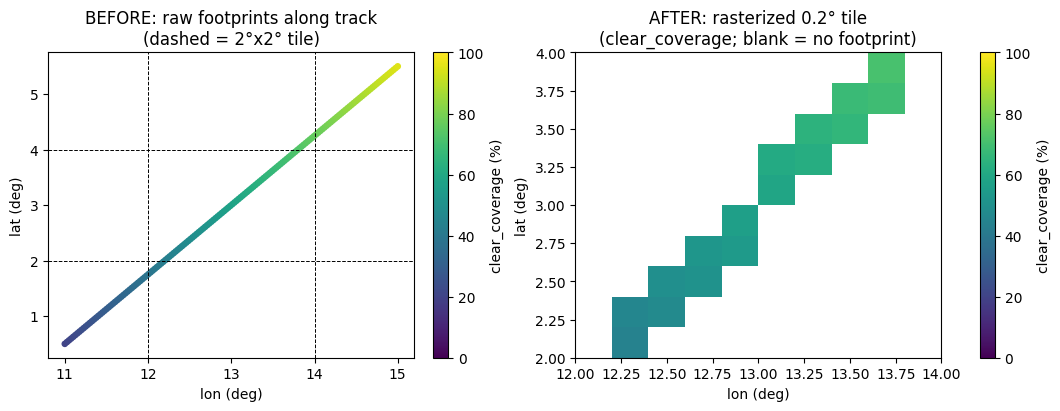

In [5]:
ssf = ReaderRegistry.get("ssf")(ssf_path)
pt_lats, pt_lons, pt_vals = ssf._load_points()  # normalized lon, flattened per-footprint values
tile = ssf.load_tile(TileKey("ssf", lat_idx=46, lon_idx=96))  # lat [2,4], lon [12,14]

cc = [v.name for v in ssf.VARIABLES].index("clear_coverage")
print(f"AFTER — tile.data.shape={tile.data.shape} (33 vars, 10x10 cells); source={tile.source!r}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)
sc = axes[0].scatter(pt_lons, pt_lats, c=pt_vals[cc], cmap="viridis", s=14, vmin=0, vmax=100)
for x in (12, 14):
    axes[0].axvline(x, color="k", lw=0.7, ls="--")
for y in (2, 4):
    axes[0].axhline(y, color="k", lw=0.7, ls="--")
axes[0].set_title("BEFORE: raw footprints along track\n(dashed = 2°x2° tile)")
axes[0].set_xlabel("lon (deg)")
axes[0].set_ylabel("lat (deg)")
fig.colorbar(sc, ax=axes[0], label="clear_coverage (%)")
im = axes[1].pcolormesh(tile.lons, tile.lats, tile.data[cc], cmap="viridis", vmin=0, vmax=100, shading="auto")
axes[1].set_title("AFTER: rasterized 0.2° tile\n(clear_coverage; blank = no footprint)")
axes[1].set_xlabel("lon (deg)")
axes[1].set_ylabel("lat (deg)")
fig.colorbar(im, ax=axes[1], label="clear_coverage (%)")
plt.show()

### 2a. Mode gating: `only_modes`

SSF carries an extended, IMAGER-only variable set (layered cloud fields, assimilated
aerosol properties, surface albedo, TOA incoming solar). Those `VariableSpec`s are pinned
with `only_modes=(IMAGER,)`, so FMATCH-CAM and FMATCH-IMAGER-FLASH products never see them
while FMATCH-IMAGER gets them automatically — one reader, mode-dependent contract.

In [6]:
base = [v.name for v in ssf.VARIABLES if not v.only_modes]
imager_only = [v.name for v in ssf.VARIABLES if v.only_modes]
print(f"base set (CAM / FLASH / IMAGER), {len(base)} vars:")
print("  " + ", ".join(base))
print(f"\nIMAGER-only extended set, {len(imager_only)} vars (only_modes=(IMAGER,)):")
print("  " + ", ".join(imager_only[:8]) + ", ...")

base set (CAM / FLASH / IMAGER), 8 vars:
  aerosol_optical_depth, clear_coverage, cloud_optical_depth_lower, cloud_water_particle_radius_lower, cloud_ice_particle_radius_lower, cloud_classification, shortwave_adm_type, longwave_adm_type

IMAGER-only extended set, 25 vars (only_modes=(IMAGER,)):
  layer_coverage_lower, layer_coverage_upper, cloud_coverage_multilayer_lower, cloud_coverage_multilayer_upper, cloud_top_pressure_lower, cloud_top_pressure_upper, cloud_base_pressure_lower, cloud_base_pressure_upper, ...


## 3. CLDPIX: a 2-D imager-pixel swath with colatitude

**Native structure** — NetCDF4, **flat root-level variables** on a 2-D
`(Scanlines, Pixels)` imager swath; every pixel carries its own geolocation. Two
conventions the reader must fix, either of which would silently corrupt the result:
`Latitude` is stored as **colatitude** (0° at the North Pole, 180° at the South Pole — so
`latitude = 90 − colatitude`), and `Longitude` is **0–360**.

**Reader transform** (`cldpix.py`): parse once (cached) → convert colatitude to latitude
and longitude to −180–180 → flatten the 2-D swath arrays to a 1-D point cloud → apply each
field's fill value and valid range (with a float32 round-trip so CERES's `3.4e38` fill is
caught) → `rasterize_points_to_grid` onto 0.05° cells (40×40 per 2° tile).

In [7]:
from tests.test_data.footprint_matching.fixtures import make_cldpix_fixture

# A 2-D pixel ribbon (scanlines x pixels) sweeping across tile [2,4]x[12,14].
nscan, npix = 60, 12
scan = np.linspace(1.0, 5.0, nscan)
across = np.linspace(-1.0, 1.0, npix)
sw_lat = (scan[:, None] + 0.15 * across[None, :]).astype(np.float32)
sw_lon = (13.0 + 1.6 * across[None, :] + 0.2 * (scan[:, None] - 3.0)).astype(np.float32)  # 0-360
cldpix_path = make_cldpix_fixture(workdir, lats=sw_lat, lons_0360=sw_lon)

# The fixture writes a constant optical depth; overwrite it with a spatial gradient so the
# "after" plot shows structure (valid_range is 0.25..150).
with netCDF4.Dataset(cldpix_path, "r+") as ds:
    ds.set_auto_mask(False)
    colat = ds["Latitude"][:]
    grad = 5.0 + 30.0 * (colat.max() - colat) / (colat.max() - colat.min())
    ds["Eff_Cld_Optical_Depth"][:] = grad.astype(np.float32)
    print("BEFORE — raw CLDPIX geolocation is COLATITUDE (0=N pole):")
    print(f"  Latitude (colatitude) range: {colat.min():.1f}..{colat.max():.1f}  -> latitude = 90 - colat")
    print(f"  swath shape (Scanlines, Pixels) = {ds['Eff_Cld_Optical_Depth'].shape}")

BEFORE — raw CLDPIX geolocation is COLATITUDE (0=N pole):
  Latitude (colatitude) range: 84.8..89.2  -> latitude = 90 - colat
  swath shape (Scanlines, Pixels) = (60, 12)


Raw pixel swath (latitude recovered from colatitude) next to the rasterized tile:

AFTER — tile.data.shape=(9, 40, 40) (9 vars, 40x40 cells)


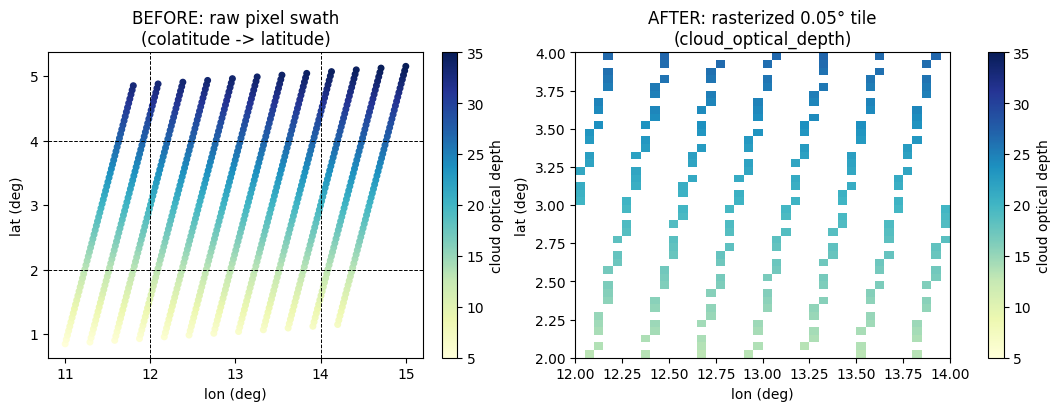

In [8]:
cldpix = ReaderRegistry.get("cldpix")(cldpix_path)
p_lats, p_lons, p_vals = cldpix._load_points()
ctile = cldpix.load_tile(TileKey("cldpix", 46, 96))
cod = [v.name for v in cldpix.VARIABLES].index("cloud_optical_depth")
print(f"AFTER — tile.data.shape={ctile.data.shape} (9 vars, 40x40 cells)")

vmin, vmax = float(np.nanmin(p_vals[cod])), float(np.nanmax(p_vals[cod]))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)
sc = axes[0].scatter(p_lons, p_lats, c=p_vals[cod], cmap="YlGnBu", s=16, vmin=vmin, vmax=vmax)
for x in (12, 14):
    axes[0].axvline(x, color="k", lw=0.7, ls="--")
for y in (2, 4):
    axes[0].axhline(y, color="k", lw=0.7, ls="--")
axes[0].set_title("BEFORE: raw pixel swath\n(colatitude -> latitude)")
axes[0].set_xlabel("lon (deg)")
axes[0].set_ylabel("lat (deg)")
fig.colorbar(sc, ax=axes[0], label="cloud optical depth")
im = axes[1].pcolormesh(ctile.lons, ctile.lats, ctile.data[cod], cmap="YlGnBu", vmin=vmin, vmax=vmax, shading="auto")
axes[1].set_title("AFTER: rasterized 0.05° tile\n(cloud_optical_depth)")
axes[1].set_xlabel("lon (deg)")
axes[1].set_ylabel("lat (deg)")
fig.colorbar(im, ax=axes[1], label="cloud optical depth")
plt.show()

## 4. VIIRS cloud (D3 daily grid): read + transpose

**Native structure** — unlike the two swath products, the VIIRS cloud D3 file is *already*
a regular 1°×1° global grid, so no rasterization is needed. The catch is packaging: each
field lives in its own **group** as a `Mean` dataset (`Cloud_Optical_Thickness_Combined/
Mean`, `Cloud_Top_Pressure/Mean`), and those arrays are stored **transposed** as
`(longitude, latitude)` with a −9999 fill.

**Reader transform** (`viirs.py`): open once (cached) → read each `Mean` from its group and
`.T` to `(latitude, longitude)` → set −9999 to NaN → slice the tile window directly. This
reader is also the only one that sets `timestamp_source="radiometer"`, because the daily
cloud grid is collocated in time with the radiometer rather than carrying its own scan
time.

In [9]:
from tests.test_data.footprint_matching.fixtures import make_viirs_cloud_d3_fixture

viirs_path = make_viirs_cloud_d3_fixture(
    workdir, n_lat=16, n_lon=16, lat_min=0.5, lat_max=7.5, lon_min=10.5, lon_max=17.5
)

# Constant fixture -> inject a smooth gradient into the (longitude, latitude) Mean array.
with netCDF4.Dataset(viirs_path, "r+") as ds:
    lat = ds["latitude"][:]
    lon = ds["longitude"][:]
    field = 9.0 + 6.0 * np.sin(lat[None, :] / 3.0) * np.cos(lon[:, None] / 4.0)  # (lon, lat) order, positive
    ds["Cloud_Optical_Thickness_Combined"]["Mean"][:] = field.astype(np.float32)
    print("BEFORE — raw VIIRS D3 file: data hidden in per-parameter groups, stored (lon, lat):")
    for gname, grp in ds.groups.items():
        v = grp["Mean"]
        print(f"  group {gname}/Mean  dims={v.dimensions} shape={v.shape}")

BEFORE — raw VIIRS D3 file: data hidden in per-parameter groups, stored (lon, lat):
  group Cloud_Fraction/Mean  dims=('longitude', 'latitude') shape=(16, 16)
  group Cloud_Optical_Thickness_Combined/Mean  dims=('longitude', 'latitude') shape=(16, 16)
  group Cloud_Top_Pressure/Mean  dims=('longitude', 'latitude') shape=(16, 16)


The reader lifts each `Mean` out of its group, transposes to `(lat, lon)`, and slices:

AFTER — tile.data.shape=(2, 4, 4) (2 vars); timestamp_source='radiometer'


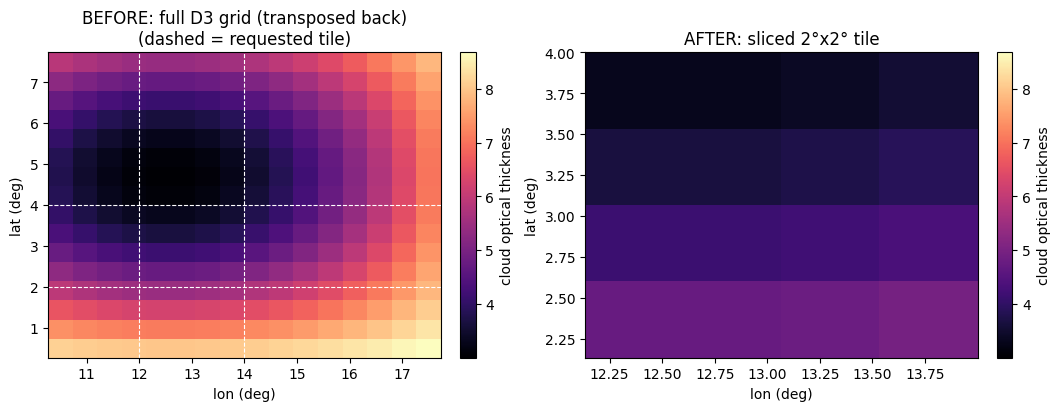

In [10]:
viirs = ReaderRegistry.get("viirs_cloud")(viirs_path)
vtile = viirs.load_tile(TileKey("viirs_cloud", 46, 96))
cot = [v.name for v in viirs.VARIABLES].index("cloud_optical_thickness")
print(f"AFTER — tile.data.shape={vtile.data.shape} (2 vars); timestamp_source={vtile.timestamp_source!r}")

with netCDF4.Dataset(viirs_path) as ds:
    raw = ds["Cloud_Optical_Thickness_Combined"]["Mean"][:].T  # (lat, lon) for display
    raw_lat = ds["latitude"][:]
    raw_lon = ds["longitude"][:]

vmin, vmax = float(np.nanmin(raw)), float(np.nanmax(raw))
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)
im0 = axes[0].pcolormesh(raw_lon, raw_lat, raw, cmap="magma", vmin=vmin, vmax=vmax, shading="auto")
for x in (12, 14):
    axes[0].axvline(x, color="w", lw=0.8, ls="--")
for y in (2, 4):
    axes[0].axhline(y, color="w", lw=0.8, ls="--")
axes[0].set_title("BEFORE: full D3 grid (transposed back)\n(dashed = requested tile)")
axes[0].set_xlabel("lon (deg)")
axes[0].set_ylabel("lat (deg)")
fig.colorbar(im0, ax=axes[0], label="cloud optical thickness")
im1 = axes[1].pcolormesh(vtile.lons, vtile.lats, vtile.data[cot], cmap="magma", vmin=vmin, vmax=vmax, shading="auto")
axes[1].set_title("AFTER: sliced 2°x2° tile")
axes[1].set_xlabel("lon (deg)")
axes[1].set_ylabel("lat (deg)")
fig.colorbar(im1, ax=axes[1], label="cloud optical thickness")
plt.show()

## Where this goes next in the stack

With all nine readers registered, the **tile manager (next PR)** can map any footprint
`BoundingBox` to the set of `TileKey`s per ancillary source, cache the loaded `GridTile`s,
and hand them to PSF-weighted aggregation (two PRs out).